# Single-precision likelihoods (and the reference--delta trick)

GPUs run *much* faster in single precision (`float32`) than in double (`float64`),
and they use half the memory. But a PTA marginal likelihood is a difference of
large numbers -- a quadratic form $\sim 10^6$ and log-determinants $\sim 10^4$ whose
*physically interesting* part is an $O(1)$ residual. Rounded at the `float32` ulp of
a $10^6$-scale number ($\approx 0.06$), that residual is swamped: a blanket `float32`
likelihood can be wrong by $0.1$--$1$ in $\ln L$, which is fatal for sampling.

Discovery offers three flavors of the same Hellings--Downs model so you can see the
trade-off directly:

| flavor | backend / dtype | idea |
|---|---|---|
| **`float64`** | graph, `float64` | the trusted baseline (the "truth") |
| **blanket `float32`** | graph, `float32` | everything in single precision -- fast, but the cancellation bites |
| **reference--delta `float32`** | graph, `float32` | single precision *with* the big cancellation done once in `float64` (see below) |

This page builds all three on a small array, runs them, and compares their precision.
We use the **standard timing model** (`project=False`) throughout to keep things simple.


In [1]:
import jax
jax.config.update("jax_enable_x64", True)   # keep float64 available globally

import numpy as np
import pandas as pd
import jax.numpy as jnp
from pathlib import Path

import discovery as ds
from discovery import utils
import matplotlib.pyplot as plt

## Data

A handful of NANOGrav 15 yr pulsars, plus an MCMC chain we draw realistic parameters
from. (Drawing from the chain matters: uniform prior draws wander into extreme regions
that make the `float32` Cholesky fail -- those are sampling artifacts, not the precision
effect we want to study.)

In [2]:
datapath = Path(ds.__path__[0]) / "../../data"
psrfiles = sorted(datapath.glob("v1p1_de440_pint_bipm2019-*.feather"))[:12]
psrs = [ds.Pulsar.read_feather(f) for f in psrfiles]
chain = pd.read_feather(datapath / "NG15yr-m3a-chain.feather")
print(f"{len(psrs)} pulsars, {sum(len(p.residuals) for p in psrs)} TOAs")

12 pulsars, 98876 TOAs


## The model

Per-pulsar intrinsic red noise (a vectorised common Fourier basis, independent
amplitudes per pulsar) plus a Hellings--Downs--correlated gravitational-wave background
(the `globalgp`, which couples the pulsars). The per-pulsar piece carries the usual
white-noise, ECORR, and timing-model terms; `makegp_timing(..., project=False)` selects
the standard (improper-prior) timing model rather than the projection variant.

The model has to be built **inside** the precision context, because the backend and
working dtype are baked in when the graph is materialised. So we wrap construction in a
helper that sets the context first.

In [3]:
# Standard per-pulsar model (red noise lives in the shared commongp).
def per_pulsar(psr):
    return ds.PulsarLikelihood([
        psr.residuals,
        ds.makenoise_measurement(psr, psr.noisedict),
        ds.makegp_ecorr(psr, psr.noisedict),
        ds.makegp_timing(psr, svd=True, project=False),   # projection OFF
    ])

# Build the per-pulsar-IRN + HD-GW ArrayLikelihood under a given precision.
def make_hd_model(psrs, *, dtype, kernels, reference=None):
    ds.config(kernels=kernels)                       # 'matrix' or 'metamath'
    utils.config(backend="jax", working=dtype)       # float32 / float64
    T = ds.getspan(psrs)
    kw = dict(
        commongp=ds.makecommongp_fourier(psrs, ds.powerlaw, components=30,
                                         T=T, name="red_noise"),
        globalgp=ds.makeglobalgp_fourier(psrs, ds.powerlaw, ds.hd_orf,
                                         components=14, T=T, name="gw"),
    )
    if reference is not None:           # reference-delta opt-in (metamath only)
        kw["reference"] = reference
    return ds.ArrayLikelihood([per_pulsar(p) for p in psrs], **kw)

## Parameters: draws and a reference point

We grab the parameter names from the model, draw a few points from the chain to test at,
and take the chain **median** as the reference point $\theta_{\rm ref}$ for the
reference--delta flavor.

In [4]:
# parameter names (build a throwaway model just to read them)
params = make_hd_model(psrs, dtype=jnp.float64, kernels="metamath").logL.params

rng = np.random.default_rng(0)
draws = [{p: float(chain[p].iloc[i]) for p in params}
         for i in rng.integers(0, len(chain), 5)]
theta_ref = {p: float(np.median(chain[p])) for p in params}   # reference = chain median
print(f"{len(params)} parameters, {len(draws)} test draws")

26 parameters, 5 test draws


## How reference--delta splits the likelihood

The reference--delta path never asks `float32` to hold a big number. It freezes the
prior covariance once at the reference point and expands the likelihood around it.

Freeze the prior covariance at $\theta_{\rm ref}$ (done once, in `float64`) and write the
current covariance as that constant plus a small change:

$$
\Phi(\theta) \;=\; \underbrace{\Phi(\theta_{\rm ref})}_{\text{frozen, float64}} \;+\; \Delta\Phi(\theta).
$$

The log-likelihood then splits into a constant reference value plus an $O(1)$ increment:

$$
\ln L(\theta) \;=\; \underbrace{\ln L_{\rm ref}}_{\text{computed once in float64}} \;+\; \Delta\!\ln L(\theta),
$$

and the increment is built **directly** from $\Delta\Phi$ (a resolvent/perturbation
identity), *not* by subtracting two large likelihoods:

$$
\Delta\!\ln L(\theta) \;=\; -\tfrac12\big[(\Delta\tilde a - \Delta Q) + \Delta\mathcal{L}_{\det}\big]
\;=\; O(1).
$$

Because $\ln L_{\rm ref}$ carries the large $\sim 10^6$ pieces (in `float64`) and the
expensive current factorisation only ever touches the $O(1)$ increment, `float32` holds a
small, well-conditioned number -- so its limited precision no longer matters.

(The full derivation lives in the developer notes; here we only need the shape of it.)

## Run all three and compare precision

In [5]:
def eval_logL(*, dtype, kernels, reference=None):
    model = make_hd_model(psrs, dtype=dtype, kernels=kernels, reference=reference)
    logL = jax.jit(model.logL)
    return np.array([float(logL(d)) for d in draws])

L_truth   = eval_logL(dtype=jnp.float64, kernels="matrix")                  # trusted baseline
L_f64     = eval_logL(dtype=jnp.float64, kernels="metamath")               # graph, float64
L_f32     = eval_logL(dtype=jnp.float32, kernels="metamath")               # blanket float32
L_f32refd = eval_logL(dtype=jnp.float32, kernels="metamath",
                      reference=theta_ref)                                  # reference-delta float32

print("typical |logL| ~", f"{np.abs(L_truth).max():.2e}")

typical |logL| ~ 1.19e+06


In [6]:
maxerr = lambda L: float(np.abs(L - L_truth).max())
summary = pd.DataFrame({
    "flavor": ["metamath float64", "blanket float32", "reference-delta float32"],
    "max |ΔlogL| vs truth": [maxerr(L_f64), maxerr(L_f32), maxerr(L_f32refd)],
})
summary

,flavor,max |ΔlogL| vs truth
0,metamath float64,1.443550e-08
1,blanket float32,6.953272e-02
2,reference-delta float32,1.086851e-03


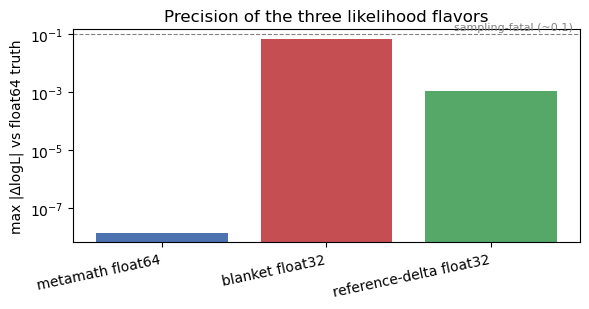

In [7]:
fig, ax = plt.subplots(figsize=(6, 3.2))
ax.bar(summary["flavor"], summary["max |ΔlogL| vs truth"],
       color=["#4c72b0", "#c44e52", "#55a868"])
ax.set_yscale("log")
ax.set_ylabel("max |ΔlogL| vs float64 truth")
ax.set_title("Precision of the three likelihood flavors")
ax.axhline(0.1, ls="--", lw=0.8, color="grey")
ax.text(2.5, 0.12, "sampling-fatal (~0.1)", ha="right", va="bottom",
        fontsize=8, color="grey")
plt.xticks(rotation=12, ha="right")
plt.tight_layout()
plt.show()

## Takeaway

- **`float64`** agrees with the trusted baseline to $\sim\!10^{-8}$ -- machine precision.
- **Blanket `float32`** is off by $\sim\!10^{-1}$: the big cancellation lands below its ulp.
  Fast and memory-light, but too imprecise to sample with at this array size, and it gets
  *worse* as the array grows.
- **Reference--delta `float32`** recovers most of the precision -- error $\sim\!10^{-3}$ --
  while staying in single precision, because the large pieces are handled once in `float64`
  and `float32` only ever holds the $O(1)$ increment.

So on a GPU you get (most of) the `float32` speed and memory savings without the precision
collapse: the reference--delta path is the one to reach for on large arrays.

> On the GPU, the `float32` floor is set by TF32 matrix multiplies (~$10^{-2}$) rather than
> the cancellation; `jax.config.update("jax_default_matmul_precision", "highest")` trades
> some speed to recover it.